# Financial Market Movement Prediction Using News Sentiment and Market Data

## Notebook 3: Model Training, Evaluation and Explainability

**Selected Stock:** Apple Inc. (AAPL)

**Objective:** Train, validate and compare Logistic Regression, Random Forest, XGBoost and LightGBM models using chronological data splits, evaluate next-day movement predictions, and explain the best model using SHAP.

In [1]:
from pathlib import Path
import warnings
import time

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# Locate project folders
project_root = (
    Path.cwd().parent
    if Path.cwd().name.lower() == "notebooks"
    else Path.cwd()
)

processed_data_dir = project_root / "data" / "processed"
models_dir = project_root / "models"
figures_dir = project_root / "outputs" / "figures"
reports_dir = project_root / "reports"

models_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

# Load the unified modeling dataset
modeling_dataset_file = (
    processed_data_dir / "AAPL_modeling_dataset.csv"
)

data = pd.read_csv(modeling_dataset_file)

data["Date"] = pd.to_datetime(data["Date"])
data.sort_values("Date", inplace=True)
data.reset_index(drop=True, inplace=True)

print("Modeling dataset shape:", data.shape)
print(
    "Date range:",
    data["Date"].min().date(),
    "to",
    data["Date"].max().date()
)

print("\nTarget distribution:")
print(data["Target"].value_counts())

display(data.head())

Modeling dataset shape: (2210, 41)
Date range: 2016-02-19 to 2024-11-27

Target distribution:
Target
1    1185
0    1025
Name: count, dtype: int64


,Date,Open,High,Low,Close,Adj Close,Volume,Next_Close,Target,Daily_Return,...,Daily_Avg_Sentiment,Daily_Positive_Score,Daily_Neutral_Score,Daily_Negative_Score,Positive_News_Count,Neutral_News_Count,Negative_News_Count,Sentiment_Volatility,News_Count,News_Available
0,2016-02-19,24.000000,24.190001,23.950001,24.010000,21.712439,141496800,24.219999,1,-0.002285,...,0.077753,0.249595,0.578563,0.171842,0.0,1.0,0.0,0.0,1.0,1
1,2016-02-22,24.077499,24.225000,23.980000,24.219999,21.902338,137123200,23.672501,0,0.008746,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0
2,2016-02-23,24.100000,24.125000,23.637501,23.672501,21.407232,127770400,24.025000,1,-0.022605,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0
3,2016-02-24,23.495001,24.094999,23.330000,24.025000,21.726004,145022800,24.190001,1,0.014891,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0
4,2016-02-25,24.012501,24.190001,23.812500,24.190001,21.875214,110330800,24.227501,1,0.006868,...,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0


In [2]:
# Exclude identifiers, the future price and the target
# Adj Close is excluded because historical adjustments can be revised
excluded_columns = [
    "Date",
    "Adj Close",
    "Next_Close",
    "Target"
]

feature_columns = [
    column
    for column in data.columns
    if column not in excluded_columns
]

X = data[feature_columns].copy()
y = data["Target"].astype(int).copy()

# Confirm the model receives only valid numerical values
X.replace([np.inf, -np.inf], np.nan, inplace=True)

print("Number of model features:", len(feature_columns))
print("Missing feature values:", X.isnull().sum().sum())

# Chronological 70%–15%–15% split
total_rows = len(data)
train_end = int(total_rows * 0.70)
validation_end = int(total_rows * 0.85)

X_train = X.iloc[:train_end].copy()
y_train = y.iloc[:train_end].copy()

X_validation = X.iloc[
    train_end:validation_end
].copy()
y_validation = y.iloc[
    train_end:validation_end
].copy()

X_test = X.iloc[validation_end:].copy()
y_test = y.iloc[validation_end:].copy()

train_dates = data["Date"].iloc[:train_end]
validation_dates = data["Date"].iloc[
    train_end:validation_end
]
test_dates = data["Date"].iloc[
    validation_end:
]

print("\nTraining samples:", len(X_train))
print(
    "Training dates:",
    train_dates.min().date(),
    "to",
    train_dates.max().date()
)

print("\nValidation samples:", len(X_validation))
print(
    "Validation dates:",
    validation_dates.min().date(),
    "to",
    validation_dates.max().date()
)

print("\nTesting samples:", len(X_test))
print(
    "Testing dates:",
    test_dates.min().date(),
    "to",
    test_dates.max().date()
)

print("\nTraining target distribution:")
print(y_train.value_counts())

Number of model features: 37
Missing feature values: 0

Training samples: 1547
Training dates: 2016-02-19 to 2022-04-08

Validation samples: 331
Validation dates: 2022-04-11 to 2023-08-04

Testing samples: 332
Testing dates: 2023-08-07 to 2024-11-27

Training target distribution:
Target
1    832
0    715
Name: count, dtype: int64


In [3]:
# Define the four required classification models
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.80,
        colsample_bytree=0.80,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=300,
        learning_rate=0.03,
        num_leaves=15,
        max_depth=5,
        min_child_samples=30,
        subsample=0.80,
        subsample_freq=1,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=1.0,
        class_weight="balanced",
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
}

trained_models = {}
validation_records = []

# Train each model only on the training period
for model_name, model in models.items():
    start_time = time.time()

    model.fit(X_train, y_train)

    validation_prediction = model.predict(
        X_validation
    )

    validation_probability = model.predict_proba(
        X_validation
    )[:, 1]

    training_seconds = time.time() - start_time

    validation_records.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_validation,
            validation_prediction
        ),
        "Precision": precision_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_validation,
            validation_probability
        ),
        "Training_Seconds": training_seconds
    })

    trained_models[model_name] = model

    print(f"{model_name} trained successfully.")

# Create the validation comparison table
validation_results = pd.DataFrame(
    validation_records
).sort_values(
    by="ROC_AUC",
    ascending=False
).reset_index(drop=True)

# Save the comparison
validation_results_file = (
    reports_dir / "model_validation_comparison.csv"
)

validation_results.to_csv(
    validation_results_file,
    index=False
)

print("\nValidation model comparison:")
display(
    validation_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1_Score": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "Training_Seconds": "{:.2f}"
    })
)

print("\nComparison saved to:")
print(validation_results_file)

Logistic Regression trained successfully.
Random Forest trained successfully.
XGBoost trained successfully.
LightGBM trained successfully.

Validation model comparison:


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Training_Seconds
0,Logistic Regression,0.4743,0.4706,0.2367,0.3150,0.4681,1.45
1,Random Forest,0.4502,0.4301,0.2367,0.3053,0.4593,1.70
2,XGBoost,0.4350,0.4224,0.2899,0.3439,0.4562,1.18
3,LightGBM,0.4441,0.4299,0.2722,0.3333,0.4399,0.41



Comparison saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\reports\model_validation_comparison.csv


In [4]:
# Check the simple validation majority-class baseline
validation_majority_accuracy = (
    y_validation.value_counts(normalize=True).max()
)

print(
    "Validation majority baseline:",
    round(validation_majority_accuracy, 4)
)

# Create scale-independent features
stationary_data = data.copy()

stationary_data["Close_vs_MA_5"] = (
    stationary_data["Close"]
    / stationary_data["MA_5"]
    - 1
)

stationary_data["Close_vs_MA_10"] = (
    stationary_data["Close"]
    / stationary_data["MA_10"]
    - 1
)

stationary_data["Close_vs_MA_20"] = (
    stationary_data["Close"]
    / stationary_data["MA_20"]
    - 1
)

stationary_data["MA_5_vs_MA_20"] = (
    stationary_data["MA_5"]
    / stationary_data["MA_20"]
    - 1
)

stationary_data["EMA_12_vs_EMA_26"] = (
    stationary_data["EMA_12"]
    / stationary_data["EMA_26"]
    - 1
)

stationary_data["MACD_Percentage"] = (
    stationary_data["MACD"]
    / stationary_data["Close"]
)

stationary_data["RSI_Normalized"] = (
    stationary_data["RSI_14"] - 50
) / 50

stationary_data["BB_Position"] = (
    stationary_data["Close"]
    - stationary_data["BB_Lower"]
) / (
    stationary_data["BB_Upper"]
    - stationary_data["BB_Lower"]
)

# Create cyclic temporal features
stationary_data["Day_Sin"] = np.sin(
    2 * np.pi
    * stationary_data["Day_of_Week"]
    / 5
)

stationary_data["Day_Cos"] = np.cos(
    2 * np.pi
    * stationary_data["Day_of_Week"]
    / 5
)

stationary_data["Month_Sin"] = np.sin(
    2 * np.pi
    * stationary_data["Month"]
    / 12
)

stationary_data["Month_Cos"] = np.cos(
    2 * np.pi
    * stationary_data["Month"]
    / 12
)

# Convert daily news counts into proportions
safe_news_count = (
    stationary_data["News_Count"]
    .replace(0, np.nan)
)

stationary_data["Positive_News_Ratio"] = (
    stationary_data["Positive_News_Count"]
    / safe_news_count
).fillna(0)

stationary_data["Neutral_News_Ratio"] = (
    stationary_data["Neutral_News_Count"]
    / safe_news_count
).fillna(0)

stationary_data["Negative_News_Ratio"] = (
    stationary_data["Negative_News_Count"]
    / safe_news_count
).fillna(0)

stationary_data["News_Count_Log"] = np.log1p(
    stationary_data["News_Count"]
)

# Select stable market, sentiment and temporal features
selected_features = [
    "Daily_Return",
    "Price_Range",
    "Open_Close_Change",
    "Volume_Change",
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "Volatility_10",
    "RSI_Normalized",
    "Close_vs_MA_5",
    "Close_vs_MA_10",
    "Close_vs_MA_20",
    "MA_5_vs_MA_20",
    "EMA_12_vs_EMA_26",
    "MACD_Percentage",
    "BB_Position",
    "BB_Width",
    "Day_Sin",
    "Day_Cos",
    "Month_Sin",
    "Month_Cos",
    "Daily_Avg_Sentiment",
    "Daily_Positive_Score",
    "Daily_Neutral_Score",
    "Daily_Negative_Score",
    "Sentiment_Volatility",
    "Positive_News_Ratio",
    "Neutral_News_Ratio",
    "Negative_News_Ratio",
    "News_Count_Log",
    "News_Available"
]

X_selected = stationary_data[
    selected_features
].copy()

X_selected.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

print("Selected feature count:", len(selected_features))
print(
    "Missing selected-feature values:",
    X_selected.isnull().sum().sum()
)

# Recreate the same chronological split
X_train = X_selected.iloc[:train_end].copy()
X_validation = X_selected.iloc[
    train_end:validation_end
].copy()
X_test = X_selected.iloc[
    validation_end:
].copy()

print("\nUpdated training shape:", X_train.shape)
print("Updated validation shape:", X_validation.shape)
print("Updated testing shape:", X_test.shape)

print("\nSelected features:")
print(selected_features)

Validation majority baseline: 0.5106
Selected feature count: 31
Missing selected-feature values: 0

Updated training shape: (1547, 31)
Updated validation shape: (331, 31)
Updated testing shape: (332, 31)

Selected features:
['Daily_Return', 'Price_Range', 'Open_Close_Change', 'Volume_Change', 'Return_Lag_1', 'Return_Lag_2', 'Return_Lag_3', 'Volatility_10', 'RSI_Normalized', 'Close_vs_MA_5', 'Close_vs_MA_10', 'Close_vs_MA_20', 'MA_5_vs_MA_20', 'EMA_12_vs_EMA_26', 'MACD_Percentage', 'BB_Position', 'BB_Width', 'Day_Sin', 'Day_Cos', 'Month_Sin', 'Month_Cos', 'Daily_Avg_Sentiment', 'Daily_Positive_Score', 'Daily_Neutral_Score', 'Daily_Negative_Score', 'Sentiment_Volatility', 'Positive_News_Ratio', 'Neutral_News_Ratio', 'Negative_News_Ratio', 'News_Count_Log', 'News_Available']


In [5]:
# Use conservative settings to reduce time-series overfitting
stationary_models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        (
            "classifier",
            LogisticRegression(
                C=0.10,
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=400,
        max_depth=6,
        min_samples_leaf=15,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=250,
        max_depth=2,
        learning_rate=0.03,
        min_child_weight=10,
        subsample=0.80,
        colsample_bytree=0.80,
        reg_lambda=5.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ),

    "LightGBM": LGBMClassifier(
        n_estimators=250,
        learning_rate=0.03,
        num_leaves=7,
        max_depth=3,
        min_child_samples=40,
        subsample=0.80,
        subsample_freq=1,
        colsample_bytree=0.80,
        reg_alpha=0.10,
        reg_lambda=5.0,
        class_weight="balanced",
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
}

trained_models = {}
validation_records = []

for model_name, model in stationary_models.items():
    start_time = time.time()

    model.fit(X_train, y_train)

    validation_prediction = model.predict(
        X_validation
    )

    validation_probability = model.predict_proba(
        X_validation
    )[:, 1]

    training_seconds = time.time() - start_time

    validation_records.append({
        "Model": model_name,
        "Accuracy": accuracy_score(
            y_validation,
            validation_prediction
        ),
        "Precision": precision_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_validation,
            validation_prediction,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_validation,
            validation_probability
        ),
        "Above_Baseline": (
            accuracy_score(
                y_validation,
                validation_prediction
            )
            - validation_majority_accuracy
        ),
        "Training_Seconds": training_seconds
    })

    trained_models[model_name] = model
    print(f"{model_name} retrained successfully.")

validation_results = pd.DataFrame(
    validation_records
).sort_values(
    by=["ROC_AUC", "F1_Score"],
    ascending=False
).reset_index(drop=True)

stationary_results_file = (
    reports_dir
    / "stationary_model_validation_comparison.csv"
)

validation_results.to_csv(
    stationary_results_file,
    index=False
)

print("\nUpdated validation comparison:")
display(
    validation_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1_Score": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "Above_Baseline": "{:+.4f}",
        "Training_Seconds": "{:.2f}"
    })
)

print("\nComparison saved to:")
print(stationary_results_file)

Logistic Regression retrained successfully.
Random Forest retrained successfully.
XGBoost retrained successfully.
LightGBM retrained successfully.

Updated validation comparison:


,Model,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Above_Baseline,Training_Seconds
0,Logistic Regression,0.4653,0.4661,0.3254,0.3833,0.4756,-0.0453,0.04
1,Random Forest,0.4834,0.4914,0.3373,0.4000,0.4620,-0.0272,1.55
2,XGBoost,0.4713,0.4844,0.5503,0.5152,0.4553,-0.0393,0.60
3,LightGBM,0.4653,0.4677,0.3432,0.3959,0.4524,-0.0453,0.15



Comparison saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\reports\stationary_model_validation_comparison.csv


In [6]:
# Separate market and sentiment feature groups
market_feature_group = [
    "Daily_Return",
    "Price_Range",
    "Open_Close_Change",
    "Volume_Change",
    "Return_Lag_1",
    "Return_Lag_2",
    "Return_Lag_3",
    "Volatility_10",
    "RSI_Normalized",
    "Close_vs_MA_5",
    "Close_vs_MA_10",
    "Close_vs_MA_20",
    "MA_5_vs_MA_20",
    "EMA_12_vs_EMA_26",
    "MACD_Percentage",
    "BB_Position",
    "BB_Width",
    "Day_Sin",
    "Day_Cos",
    "Month_Sin",
    "Month_Cos"
]

combined_feature_group = selected_features.copy()

feature_groups = {
    "Market Only": market_feature_group,
    "Market + Sentiment": combined_feature_group
}

# Test training windows without touching the test period
training_windows = {
    "All History": pd.Timestamp("2016-02-19"),
    "From 2019": pd.Timestamp("2019-01-01"),
    "From 2020": pd.Timestamp("2020-01-01"),
    "From 2021": pd.Timestamp("2021-01-01")
}

def create_diagnostic_models():
    return {
        "Logistic Regression": Pipeline([
            ("scaler", StandardScaler()),
            (
                "classifier",
                LogisticRegression(
                    C=0.10,
                    max_iter=2000,
                    class_weight="balanced",
                    random_state=42
                )
            )
        ]),

        "Random Forest": RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=15,
            max_features="sqrt",
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ),

        "XGBoost": XGBClassifier(
            n_estimators=200,
            max_depth=2,
            learning_rate=0.03,
            min_child_weight=10,
            subsample=0.80,
            colsample_bytree=0.80,
            reg_lambda=5.0,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ),

        "LightGBM": LGBMClassifier(
            n_estimators=200,
            learning_rate=0.03,
            num_leaves=7,
            max_depth=3,
            min_child_samples=40,
            reg_lambda=5.0,
            class_weight="balanced",
            random_state=42,
            verbosity=-1,
            n_jobs=-1
        )
    }

diagnostic_records = []

validation_index = stationary_data.index[
    train_end:validation_end
]

for window_name, window_start in training_windows.items():
    training_mask = (
        (stationary_data.index < train_end)
        & (stationary_data["Date"] >= window_start)
    )

    for feature_group_name, columns in feature_groups.items():
        diagnostic_X_train = X_selected.loc[
            training_mask,
            columns
        ]
        diagnostic_y_train = y.loc[
            training_mask
        ]

        diagnostic_X_validation = X_selected.loc[
            validation_index,
            columns
        ]

        for model_name, candidate_model in (
            create_diagnostic_models().items()
        ):
            candidate_model.fit(
                diagnostic_X_train,
                diagnostic_y_train
            )

            candidate_prediction = (
                candidate_model.predict(
                    diagnostic_X_validation
                )
            )

            candidate_probability = (
                candidate_model.predict_proba(
                    diagnostic_X_validation
                )[:, 1]
            )

            diagnostic_records.append({
                "Window": window_name,
                "Feature_Group": feature_group_name,
                "Model": model_name,
                "Training_Rows": len(
                    diagnostic_X_train
                ),
                "Accuracy": accuracy_score(
                    y_validation,
                    candidate_prediction
                ),
                "F1_Score": f1_score(
                    y_validation,
                    candidate_prediction,
                    zero_division=0
                ),
                "ROC_AUC": roc_auc_score(
                    y_validation,
                    candidate_probability
                )
            })

diagnostic_results = pd.DataFrame(
    diagnostic_records
).sort_values(
    by=["ROC_AUC", "Accuracy"],
    ascending=False
).reset_index(drop=True)

diagnostic_file = (
    reports_dir
    / "training_window_feature_diagnostics.csv"
)

diagnostic_results.to_csv(
    diagnostic_file,
    index=False
)

print("Top 10 validation combinations:")
display(
    diagnostic_results.head(10).style.format({
        "Accuracy": "{:.4f}",
        "F1_Score": "{:.4f}",
        "ROC_AUC": "{:.4f}"
    })
)

print("\nDiagnostic results saved to:")
print(diagnostic_file)

Top 10 validation combinations:


,Window,Feature_Group,Model,Training_Rows,Accuracy,F1_Score,ROC_AUC
0,From 2020,Market + Sentiment,Logistic Regression,573,0.5076,0.5046,0.4963
1,From 2019,Market Only,Random Forest,825,0.4985,0.5230,0.4882
2,From 2019,Market + Sentiment,Logistic Regression,825,0.4743,0.3830,0.4857
3,From 2020,Market Only,Logistic Regression,573,0.5227,0.5753,0.4855
4,From 2019,Market Only,Logistic Regression,825,0.5015,0.5352,0.4830
5,From 2021,Market + Sentiment,Logistic Regression,320,0.4864,0.5278,0.4787
6,From 2021,Market Only,LightGBM,320,0.4955,0.5425,0.4780
7,All History,Market Only,Random Forest,1547,0.4804,0.5196,0.4766
8,All History,Market + Sentiment,Logistic Regression,1547,0.4653,0.3833,0.4756
9,From 2019,Market + Sentiment,Random Forest,825,0.4683,0.3803,0.4731



Diagnostic results saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\reports\training_window_feature_diagnostics.csv


In [7]:
# Lock the final configuration selected using validation results
final_feature_columns = market_feature_group.copy()
final_training_start = pd.Timestamp("2020-01-01")

# Combine training and validation periods
final_training_mask = (
    (stationary_data.index < validation_end)
    & (
        stationary_data["Date"]
        >= final_training_start
    )
)

final_test_index = stationary_data.index[
    validation_end:
]

X_final_train = X_selected.loc[
    final_training_mask,
    final_feature_columns
]

y_final_train = y.loc[
    final_training_mask
]

X_final_test = X_selected.loc[
    final_test_index,
    final_feature_columns
]

y_final_test = y.loc[
    final_test_index
]

# Train the locked final model
final_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            C=0.10,
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

final_model.fit(
    X_final_train,
    y_final_train
)

# Evaluate once on the untouched test period
final_test_prediction = final_model.predict(
    X_final_test
)

final_test_probability = final_model.predict_proba(
    X_final_test
)[:, 1]

final_test_accuracy = accuracy_score(
    y_final_test,
    final_test_prediction
)

final_test_precision = precision_score(
    y_final_test,
    final_test_prediction,
    zero_division=0
)

final_test_recall = recall_score(
    y_final_test,
    final_test_prediction,
    zero_division=0
)

final_test_f1 = f1_score(
    y_final_test,
    final_test_prediction,
    zero_division=0
)

final_test_auc = roc_auc_score(
    y_final_test,
    final_test_probability
)

test_majority_baseline = (
    y_final_test.value_counts(
        normalize=True
    ).max()
)

print("FINAL TEST RESULTS")
print("------------------")
print(
    f"Majority baseline: {test_majority_baseline:.4f}"
)
print(
    f"Accuracy:          {final_test_accuracy:.4f}"
)
print(
    f"Precision:         {final_test_precision:.4f}"
)
print(
    f"Recall:            {final_test_recall:.4f}"
)
print(
    f"F1-score:          {final_test_f1:.4f}"
)
print(
    f"ROC-AUC:           {final_test_auc:.4f}"
)

print("\nFinal classification report:")
print(
    classification_report(
        y_final_test,
        final_test_prediction,
        digits=4
    )
)

# Save predictions for the evaluation report
final_test_results = pd.DataFrame({
    "Date": stationary_data.loc[
        final_test_index,
        "Date"
    ].values,
    "Actual_Target": y_final_test.values,
    "Predicted_Target": final_test_prediction,
    "Up_Probability": final_test_probability
})

final_test_results_file = (
    reports_dir / "final_test_predictions.csv"
)

final_test_results.to_csv(
    final_test_results_file,
    index=False
)

# Save the final model together with its feature metadata
final_model_bundle = {
    "model": final_model,
    "feature_columns": final_feature_columns,
    "training_start": str(
        final_training_start.date()
    ),
    "target_definition": (
        "1 if next trading-day Close is greater "
        "than current Close, otherwise 0"
    )
}

final_model_file = (
    models_dir
    / "aapl_movement_logistic_model.joblib"
)

joblib.dump(
    final_model_bundle,
    final_model_file
)

print("\nFinal predictions saved to:")
print(final_test_results_file)

print("\nFinal model saved to:")
print(final_model_file)

FINAL TEST RESULTS
------------------
Majority baseline: 0.5542
Accuracy:          0.5542
Precision:         0.5874
Recall:            0.6576
F1-score:          0.6205
ROC-AUC:           0.5382

Final classification report:
              precision    recall  f1-score   support

           0     0.5000    0.4257    0.4599       148
           1     0.5874    0.6576    0.6205       184

    accuracy                         0.5542       332
   macro avg     0.5437    0.5416    0.5402       332
weighted avg     0.5484    0.5542    0.5489       332


Final predictions saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\reports\final_test_predictions.csv

Final model saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\models\aapl_movement_logistic_model.joblib


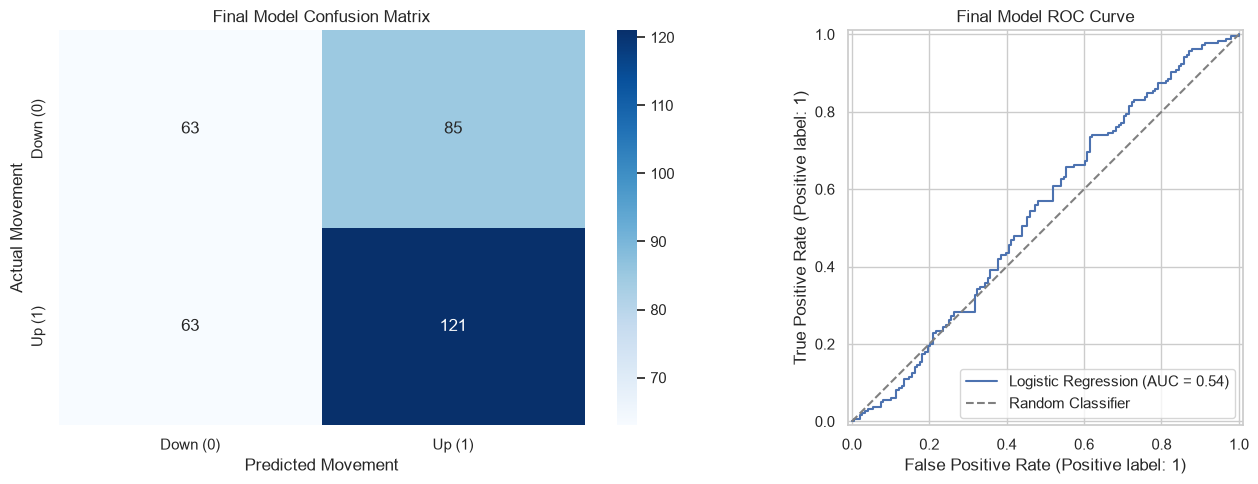

Final evaluation graph saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\outputs\figures\final_model_evaluation.png


In [9]:
# Calculate the final confusion matrix
final_confusion_matrix = confusion_matrix(
    y_final_test,
    final_test_prediction
)

# Create confusion-matrix and ROC-curve graphs
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Down (0)",
        "Up (1)"
    ],
    yticklabels=[
        "Down (0)",
        "Up (1)"
    ],
    ax=axes[0]
)

axes[0].set_title(
    "Final Model Confusion Matrix"
)
axes[0].set_xlabel(
    "Predicted Movement"
)
axes[0].set_ylabel(
    "Actual Movement"
)

RocCurveDisplay.from_predictions(
    y_final_test,
    final_test_probability,
    name="Logistic Regression",
    ax=axes[1]
)

axes[1].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Random Classifier"
)

axes[1].set_title(
    "Final Model ROC Curve"
)
axes[1].legend(loc="lower right")

plt.tight_layout()

final_evaluation_figure = (
    figures_dir
    / "final_model_evaluation.png"
)

plt.savefig(
    final_evaluation_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Final evaluation graph saved to:")
print(final_evaluation_figure)

Background dataset has 904 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=904 when initializing the masker.


Top 10 influential features:


,Feature,Mean_Absolute_SHAP
0,BB_Position,0.242376
1,RSI_Normalized,0.093865
2,Daily_Return,0.085574
3,Month_Cos,0.072126
4,Close_vs_MA_5,0.064299
5,Close_vs_MA_10,0.062936
6,Month_Sin,0.058724
7,Volatility_10,0.050600
8,MACD_Percentage,0.049535
9,Open_Close_Change,0.049047


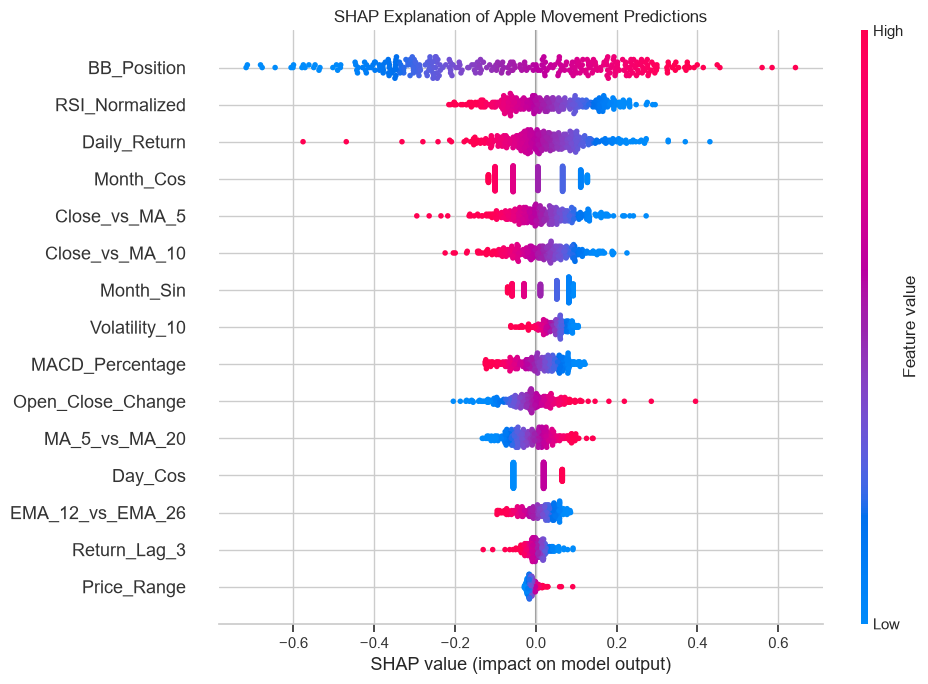


SHAP ranking saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\reports\final_model_shap_importance.csv

SHAP graph saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\outputs\figures\final_model_shap_summary.png


In [11]:
import shap

# Extract the scaler and classifier from the final pipeline
final_scaler = final_model.named_steps["scaler"]
final_classifier = final_model.named_steps[
    "classifier"
]

# Scale the training and testing features
X_final_train_scaled = final_scaler.transform(
    X_final_train
)

X_final_test_scaled = final_scaler.transform(
    X_final_test
)

# Create a dataframe containing the correct feature names
X_final_test_scaled_df = pd.DataFrame(
    X_final_test_scaled,
    columns=final_feature_columns,
    index=X_final_test.index
)

# Create the SHAP explainer
shap_explainer = shap.LinearExplainer(
    final_classifier,
    X_final_train_scaled
)

# Calculate SHAP values for the test data
shap_values = shap_explainer(
    X_final_test_scaled
)

# Calculate the average absolute importance of each feature
mean_absolute_shap = np.abs(
    shap_values.values
).mean(axis=0)

# Create the feature-importance ranking
shap_importance = pd.DataFrame({
    "Feature": final_feature_columns,
    "Mean_Absolute_SHAP": mean_absolute_shap
}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# Save the SHAP importance ranking
shap_importance_file = (
    reports_dir
    / "final_model_shap_importance.csv"
)

shap_importance.to_csv(
    shap_importance_file,
    index=False
)

print("Top 10 influential features:")
display(shap_importance.head(10))

# Create the corrected SHAP summary graph
plt.figure()

shap.summary_plot(
    shap_values.values,
    X_final_test_scaled_df,
    feature_names=final_feature_columns,
    max_display=15,
    show=False,
    plot_size=(10, 7)
)

plt.title(
    "SHAP Explanation of Apple Movement Predictions"
)

plt.tight_layout()

# Save the corrected SHAP graph
shap_summary_file = (
    figures_dir
    / "final_model_shap_summary.png"
)

plt.savefig(
    shap_summary_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSHAP ranking saved to:")
print(shap_importance_file)

print("\nSHAP graph saved to:")
print(shap_summary_file)

In [12]:
# Prepare the combined market-and-sentiment features
combined_feature_columns = combined_feature_group.copy()

X_combined_final_train = X_selected.loc[
    final_training_mask,
    combined_feature_columns
]

X_combined_final_test = X_selected.loc[
    final_test_index,
    combined_feature_columns
]

# Train the same model with sentiment features included
combined_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            C=0.10,
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )
    )
])

combined_model.fit(
    X_combined_final_train,
    y_final_train
)

combined_test_prediction = combined_model.predict(
    X_combined_final_test
)

combined_test_probability = combined_model.predict_proba(
    X_combined_final_test
)[:, 1]

# Create an ablation comparison table
ablation_results = pd.DataFrame([
    {
        "Feature_Set": "Market Only",
        "Accuracy": final_test_accuracy,
        "Precision": final_test_precision,
        "Recall": final_test_recall,
        "F1_Score": final_test_f1,
        "ROC_AUC": final_test_auc
    },
    {
        "Feature_Set": "Market + Sentiment",
        "Accuracy": accuracy_score(
            y_final_test,
            combined_test_prediction
        ),
        "Precision": precision_score(
            y_final_test,
            combined_test_prediction,
            zero_division=0
        ),
        "Recall": recall_score(
            y_final_test,
            combined_test_prediction,
            zero_division=0
        ),
        "F1_Score": f1_score(
            y_final_test,
            combined_test_prediction,
            zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            y_final_test,
            combined_test_probability
        )
    }
])

ablation_results["Accuracy_vs_Baseline"] = (
    ablation_results["Accuracy"]
    - test_majority_baseline
)

# Save the ablation results
ablation_results_file = (
    reports_dir
    / "sentiment_ablation_comparison.csv"
)

ablation_results.to_csv(
    ablation_results_file,
    index=False
)

print("Sentiment contribution analysis:")
display(
    ablation_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1_Score": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "Accuracy_vs_Baseline": "{:+.4f}"
    })
)

print("\nAblation comparison saved to:")
print(ablation_results_file)

Sentiment contribution analysis:


,Feature_Set,Accuracy,Precision,Recall,F1_Score,ROC_AUC,Accuracy_vs_Baseline
0,Market Only,0.5542,0.5874,0.6576,0.6205,0.5382,+0.0000
1,Market + Sentiment,0.5120,0.5534,0.6196,0.5846,0.4920,-0.0422



Ablation comparison saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\reports\sentiment_ablation_comparison.csv


Background dataset has 904 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=904 when initializing the masker.


Sentiment feature SHAP impact:


,Feature,Mean_Absolute_SHAP
0,News_Count_Log,0.111739
1,Daily_Neutral_Score,0.103631
2,Positive_News_Ratio,0.098611
3,Sentiment_Volatility,0.067855
4,Daily_Avg_Sentiment,0.037237
5,News_Available,0.033914
6,Daily_Positive_Score,0.030052
7,Daily_Negative_Score,0.009656
8,Negative_News_Ratio,0.000630
9,Neutral_News_Ratio,0.000364



Sentiment share of combined-model SHAP importance: 30.31%


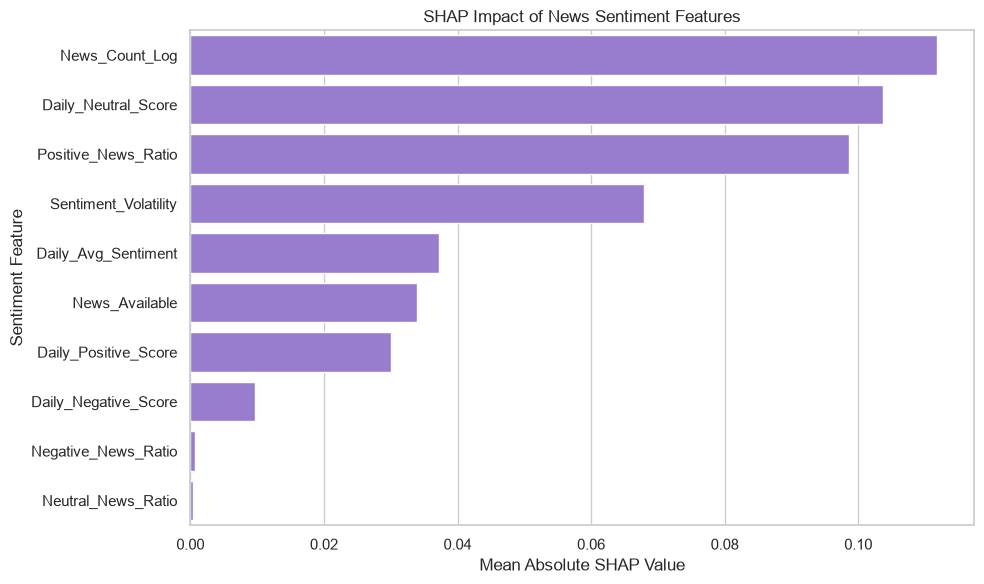


Sentiment SHAP results saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\reports\sentiment_features_shap_impact.csv

Sentiment SHAP graph saved to:
c:\Users\Boya_\OneDrive\Desktop\Financial_Market_Prediction\outputs\figures\sentiment_shap_impact.png


In [13]:
# Extract the combined model components
combined_scaler = combined_model.named_steps[
    "scaler"
]

combined_classifier = combined_model.named_steps[
    "classifier"
]

# Scale the combined datasets
X_combined_train_scaled = combined_scaler.transform(
    X_combined_final_train
)

X_combined_test_scaled = combined_scaler.transform(
    X_combined_final_test
)

# Calculate SHAP values for the combined model
combined_shap_explainer = shap.LinearExplainer(
    combined_classifier,
    X_combined_train_scaled
)

combined_shap_values = combined_shap_explainer(
    X_combined_test_scaled
)

# Calculate mean absolute SHAP importance
combined_mean_shap = np.abs(
    combined_shap_values.values
).mean(axis=0)

combined_shap_importance = pd.DataFrame({
    "Feature": combined_feature_columns,
    "Mean_Absolute_SHAP": combined_mean_shap
}).sort_values(
    by="Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# Identify the sentiment-related features
sentiment_explanation_features = [
    feature
    for feature in combined_feature_columns
    if feature not in market_feature_group
]

sentiment_shap_impact = (
    combined_shap_importance[
        combined_shap_importance["Feature"].isin(
            sentiment_explanation_features
        )
    ]
    .sort_values(
        by="Mean_Absolute_SHAP",
        ascending=False
    )
    .reset_index(drop=True)
)

# Calculate market-versus-sentiment importance shares
market_shap_total = (
    combined_shap_importance[
        combined_shap_importance["Feature"].isin(
            market_feature_group
        )
    ]["Mean_Absolute_SHAP"].sum()
)

sentiment_shap_total = (
    sentiment_shap_impact[
        "Mean_Absolute_SHAP"
    ].sum()
)

total_shap_importance = (
    market_shap_total
    + sentiment_shap_total
)

sentiment_importance_share = (
    sentiment_shap_total
    / total_shap_importance
)

# Save sentiment SHAP results
sentiment_shap_file = (
    reports_dir
    / "sentiment_features_shap_impact.csv"
)

sentiment_shap_impact.to_csv(
    sentiment_shap_file,
    index=False
)

print("Sentiment feature SHAP impact:")
display(sentiment_shap_impact)

print(
    "\nSentiment share of combined-model "
    f"SHAP importance: "
    f"{sentiment_importance_share:.2%}"
)

# Plot the sentiment-feature importance
plt.figure(figsize=(10, 6))

sns.barplot(
    data=sentiment_shap_impact,
    x="Mean_Absolute_SHAP",
    y="Feature",
    color="mediumpurple"
)

plt.title(
    "SHAP Impact of News Sentiment Features"
)
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Sentiment Feature")
plt.tight_layout()

sentiment_shap_figure = (
    figures_dir
    / "sentiment_shap_impact.png"
)

plt.savefig(
    sentiment_shap_figure,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSentiment SHAP results saved to:")
print(sentiment_shap_file)

print("\nSentiment SHAP graph saved to:")
print(sentiment_shap_figure)